In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
file_path = "/Users/dawson/Downloads/churn-bigml-80.csv"
df = pd.read_csv(file_path)



In [4]:
df.head()
print(df["Churn"].value_counts())
print()

Churn
False    2278
True      388
Name: count, dtype: int64



In [5]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [6]:
df.describe()


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [7]:
# Check for Missing Values
df.isnull().sum()


State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

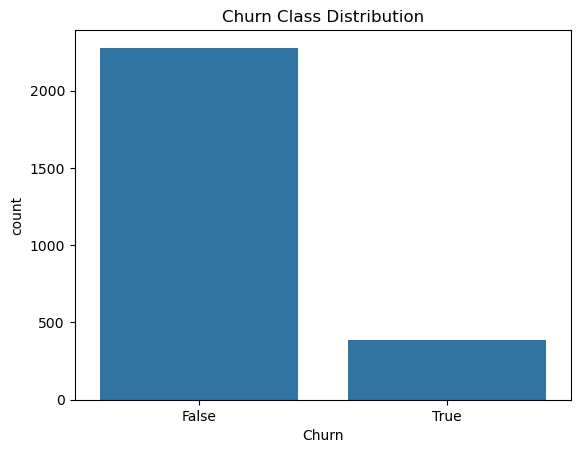

In [8]:
# Target Variable

df["Churn"].value_counts()
sns.countplot(x="Churn", data=df)
plt.title("Churn Class Distribution")
plt.show()


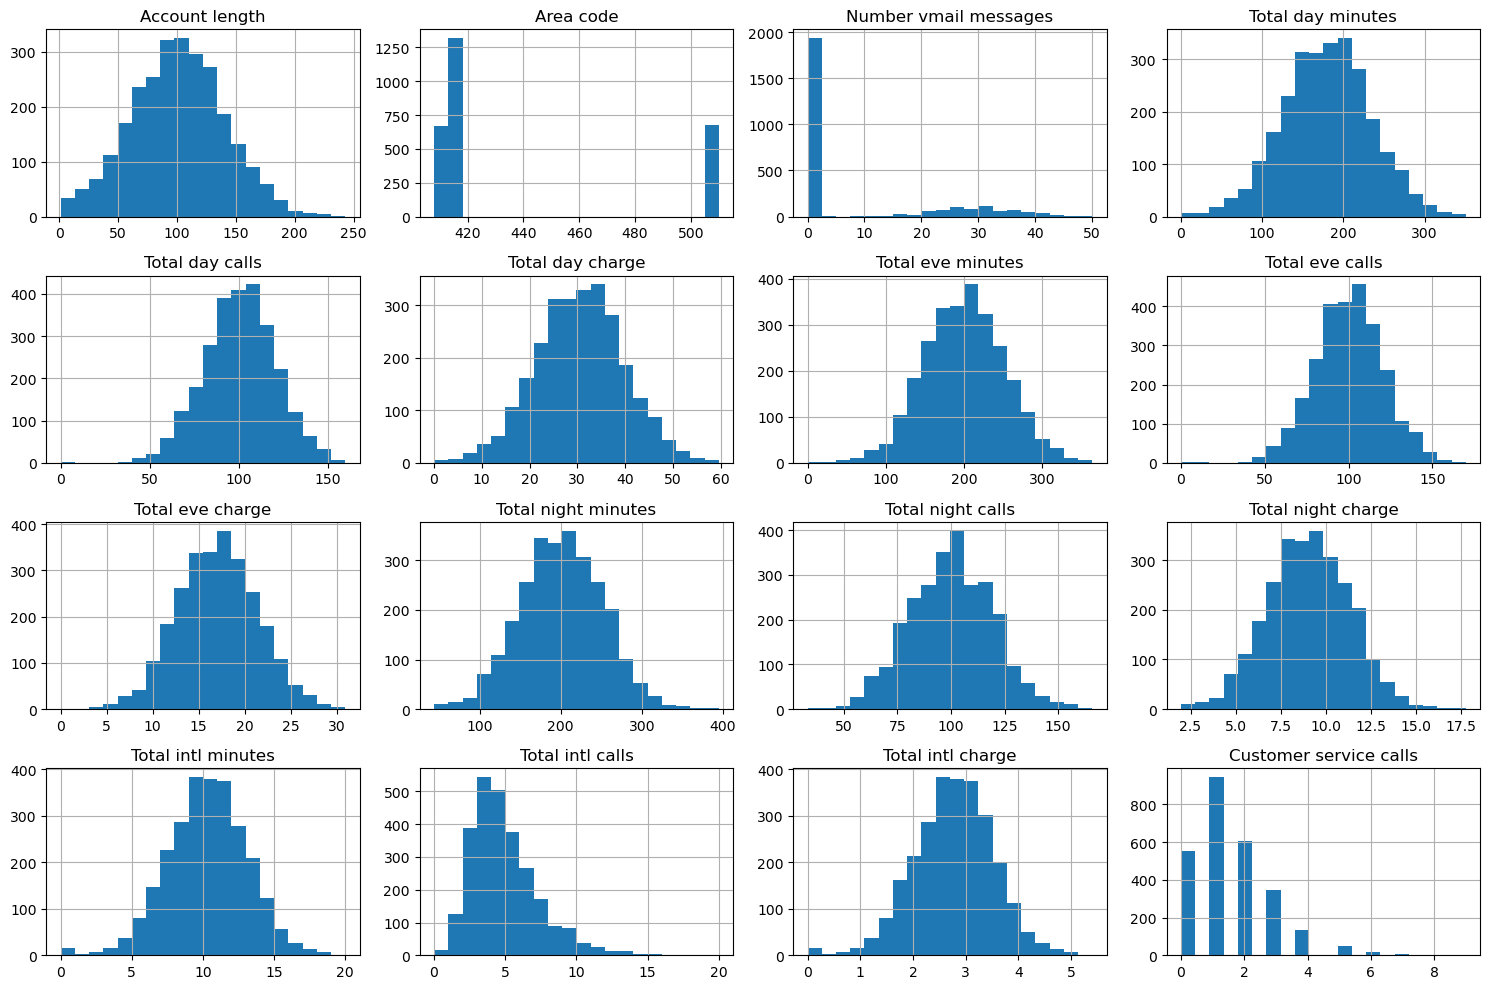

In [9]:
# Numeric Data
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols
df[numeric_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()


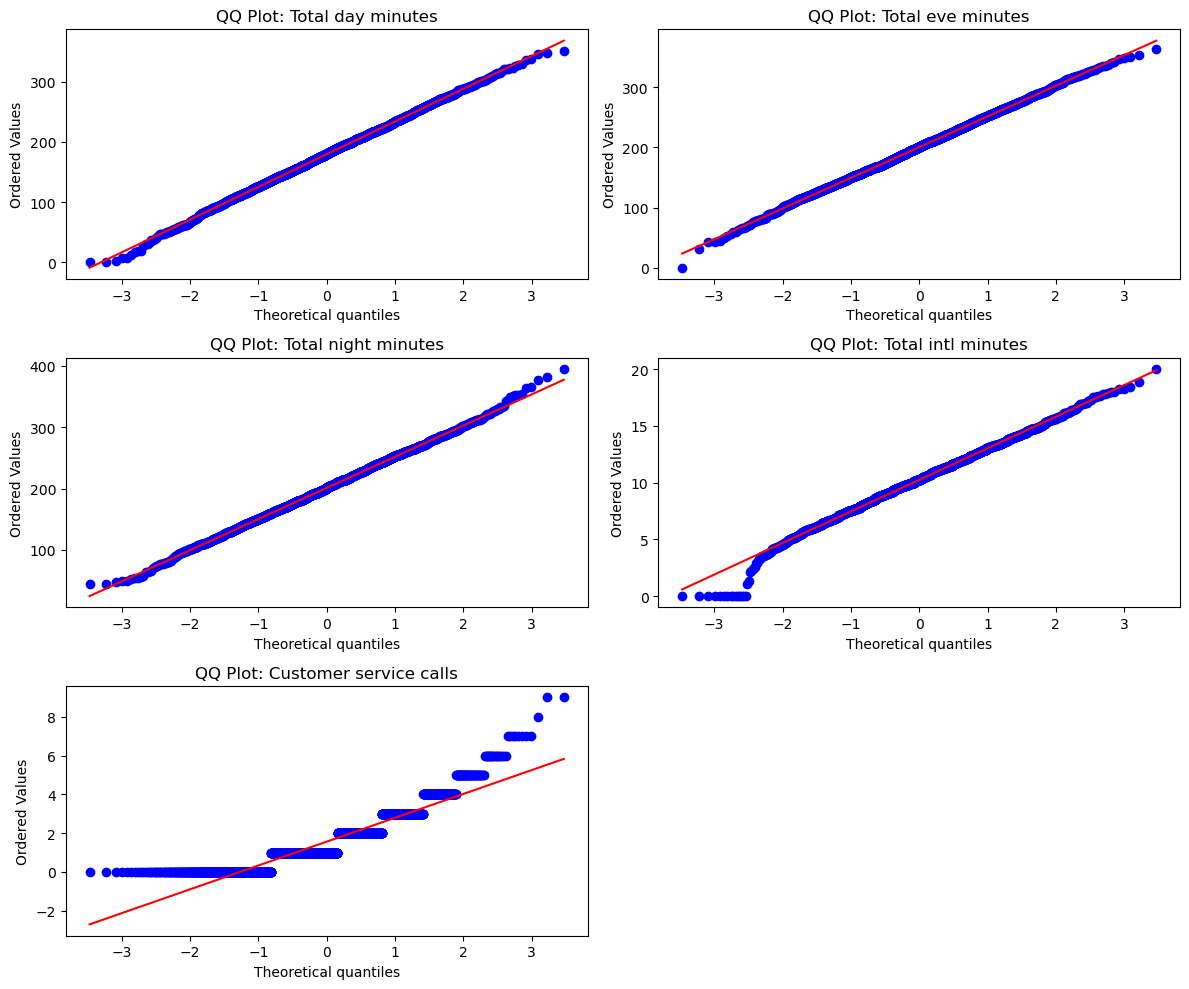

In [10]:
from scipy import stats
qq_features = [
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Customer service calls"
]

plt.figure(figsize=(12, 10))

for i, col in enumerate(qq_features, 1):
    plt.subplot(3, 2, i)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"QQ Plot: {col}")

plt.tight_layout()
plt.show()


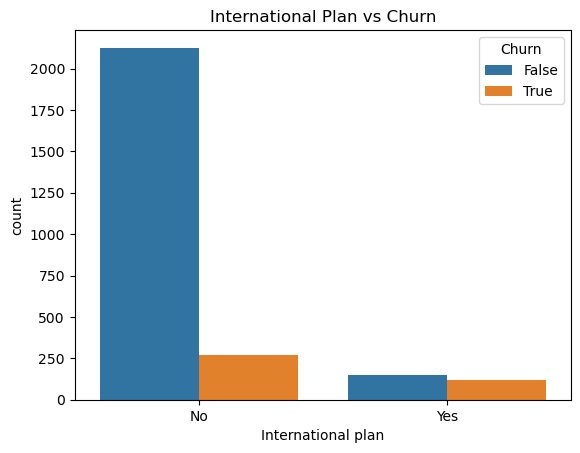

In [11]:
# Categorical Data
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns
categorical_cols
df["International plan"].value_counts()
sns.countplot(x="International plan", hue="Churn", data=df)
plt.title("International Plan vs Churn")
plt.show()


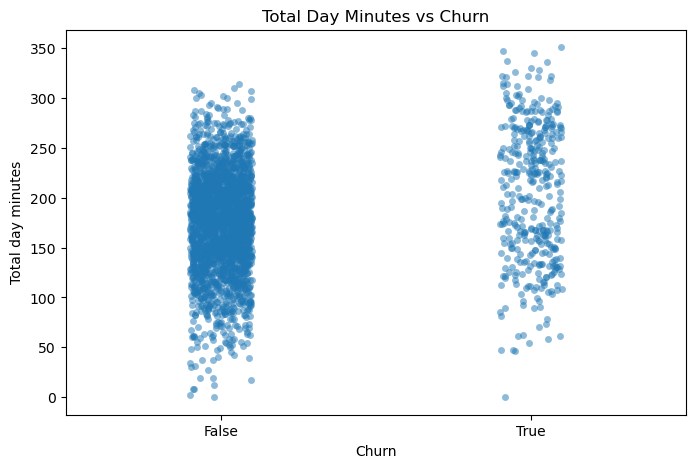

In [12]:
plt.figure(figsize=(8, 5))
sns.stripplot(
    x="Churn",
    y="Total day minutes",
    data=df,
    jitter=True,
    alpha=0.5
)
plt.title("Total Day Minutes vs Churn")
plt.show()


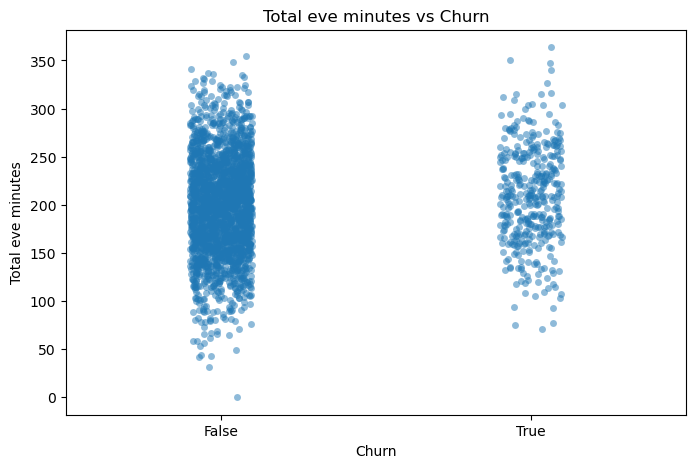

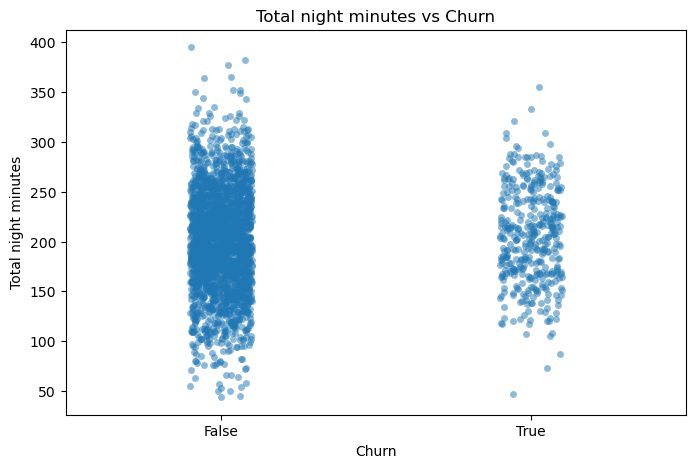

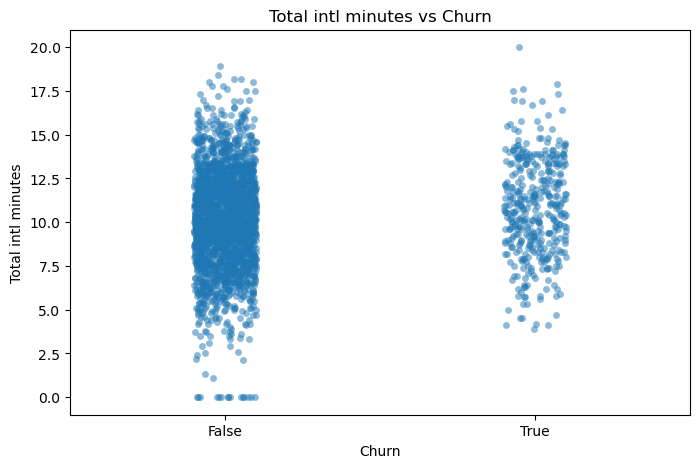

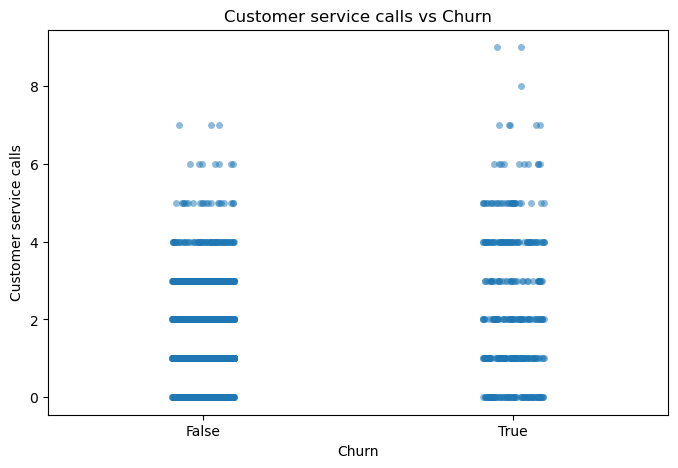

In [13]:
features_to_plot = [
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Customer service calls"
]

for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.stripplot(
        x="Churn",
        y=col,
        data=df,
        jitter=True,
        alpha=0.5
    )
    plt.title(f"{col} vs Churn")
    plt.show()


In [14]:
# Feature Creation

df["day_intensity"] = df["Total day minutes"] / df["Account length"]

#cost ratio
df["day_cost_per_min"] = df["Total day charge"] / df["Total day minutes"]
# Customer Service Stress indicator
df["high_service_calls"] = (df["Customer service calls"] >= 4).astype(int)
# create binary indicators
df["intl_plan_flag"] = (df["International plan"] == "Yes").astype(int)
df["vmail_plan_flag"] = (df["Voice mail plan"] == "Yes").astype(int)



In [15]:
pd.crosstab(df["International plan"], df["Churn"], normalize="index")


Churn,False,True
International plan,,
No,0.887312,0.112688
Yes,0.562963,0.437037


In [16]:
df["Total day minutes"].describe(percentiles=[0.95, 0.99])


count    2666.00000
mean      179.48162
std        54.21035
min         0.00000
50%       179.95000
95%       269.77500
99%       302.87500
max       350.80000
Name: Total day minutes, dtype: float64

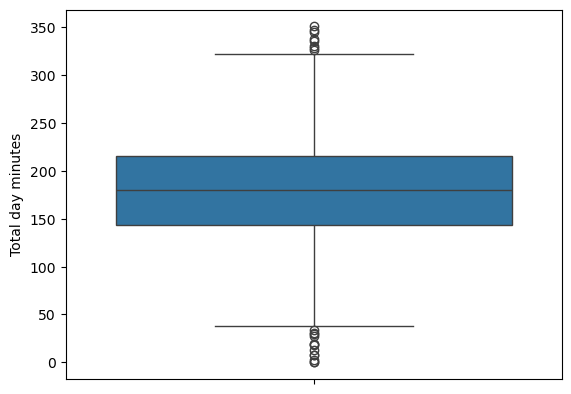

In [17]:
sns.boxplot(y=df["Total day minutes"])
plt.show()



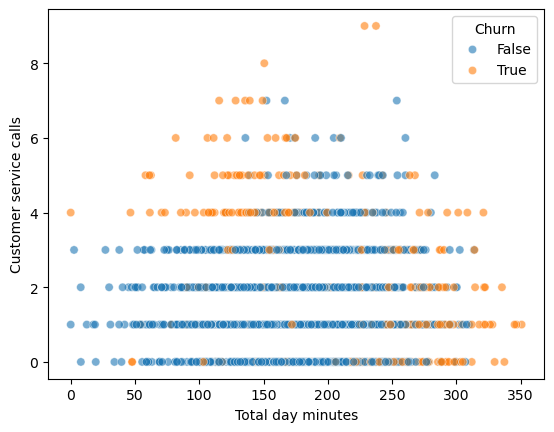

In [18]:
sns.scatterplot(
    data=df,
    x="Total day minutes",
    y="Customer service calls",
    hue="Churn",
    alpha=0.6
)
plt.show()


Usage doesn't seem to be a strong indicator of churn as much as service calls does. 

In [19]:
df_pre = df.copy()

# No Missing-Value

In [20]:
# Normalize Common String Values (consistency cleanup)
#   - trims whitespace
#   - normalizes case for Yes/No-like fields

# Identify object columns
obj_cols = df_pre.select_dtypes(include=["object"]).columns.tolist()

for c in obj_cols:
    df_pre[c] = df_pre[c].astype(str).str.strip()

# Common yes/no normalization
yes_set = {"yes", "y", "true", "t", "1"}
no_set  = {"no", "n", "false", "f", "0"}

def normalize_yes_no(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in yes_set:
        return "Yes"
    if s in no_set:
        return "No"
    return x  # leave untouched if not clearly yes/no

for c in obj_cols:
    # only apply if the column looks like it contains yes/no values
    sample = df_pre[c].dropna().astype(str).str.lower().head(200).unique().tolist()
    if any(v in yes_set or v in no_set for v in sample):
        df_pre[c] = df_pre[c].apply(normalize_yes_no)

display(df_pre[obj_cols].head())

,State,International plan,Voice mail plan
0,KS,No,Yes
1,OH,No,Yes
2,NJ,No,No
3,OH,Yes,No
4,OK,Yes,No


In [21]:
# Fix Data Types

# Categorical identifiers
df["State"] = df["State"].astype("category")
df["Area code"] = df["Area code"].astype("category")

# Binary plan indicators
df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})

df.dtypes

State                     category
Account length               int64
Area code                 category
International plan           int64
Voice mail plan              int64
Number vmail messages        int64
Total day minutes          float64
Total day calls              int64
Total day charge           float64
Total eve minutes          float64
Total eve calls              int64
Total eve charge           float64
Total night minutes        float64
Total night calls            int64
Total night charge         float64
Total intl minutes         float64
Total intl calls             int64
Total intl charge          float64
Customer service calls       int64
Churn                         bool
day_intensity              float64
day_cost_per_min           float64
high_service_calls           int64
intl_plan_flag               int64
vmail_plan_flag              int64
dtype: object

In [22]:
# Create a copy of the original dataframe for feature engineering
df_fe = df.copy()

df_fe = df_fe.drop(columns=['State', 'Area code'])

df_fe['total_minutes'] = (
    df_fe['Total day minutes'] +
    df_fe['Total eve minutes'] +
    df_fe['Total night minutes'] +
    df_fe['Total intl minutes']
)

df_fe['total_charges'] = (
    df_fe['Total day charge'] +
    df_fe['Total eve charge'] +
    df_fe['Total night charge'] +
    df_fe['Total intl charge']
)

df_fe['high_service_calls'] = (
    df_fe['Customer service calls'] >= 3
).astype(int)

df_fe['intl_usage_ratio'] = (
    df_fe['Total intl minutes'] / df_fe['total_minutes']
)

df_fe['intl_usage_ratio'] = df_fe['intl_usage_ratio'].fillna(0)

df_fe['account_length_group'] = pd.cut(
    df_fe['Account length'],
    bins=[0, 50, 150, df_fe['Account length'].max()],
    labels=['new', 'mid', 'long']
)

categorical_cols = [
    'International plan',
    'Voice mail plan',
    'account_length_group'
]

df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)
df_fe = df_fe.fillna(0)  # ← FIX: drops NaNs introduced by pd.cut edge cases

numeric_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Churn', errors='ignore')

scaler = StandardScaler()
df_fe[numeric_cols] = scaler.fit_transform(df_fe[numeric_cols])

#cast for boolean 
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn'].astype(int)  

In [23]:
# Basic structure check
df_fe.shape

(2666, 28)

In [24]:
# Column types and non-null counts
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Account length             2666 non-null   float64
 1   Number vmail messages      2666 non-null   float64
 2   Total day minutes          2666 non-null   float64
 3   Total day calls            2666 non-null   float64
 4   Total day charge           2666 non-null   float64
 5   Total eve minutes          2666 non-null   float64
 6   Total eve calls            2666 non-null   float64
 7   Total eve charge           2666 non-null   float64
 8   Total night minutes        2666 non-null   float64
 9   Total night calls          2666 non-null   float64
 10  Total night charge         2666 non-null   float64
 11  Total intl minutes         2666 non-null   float64
 12  Total intl calls           2666 non-null   float64
 13  Total intl charge          2666 non-null   float

In [25]:
# Quick preview
df_fe.head()

,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,...,high_service_calls,intl_plan_flag,vmail_plan_flag,total_minutes,total_charges,intl_usage_ratio,International plan_1,Voice mail plan_1,account_length_group_mid,account_length_group_long
0,0.692163,1.247508,1.579670,0.484868,1.579942,-0.058619,-0.050781,-0.058445,0.857403,-0.469031,...,-0.514496,-0.335690,1.623917,1.395962,1.545571,-0.667404,False,True,True,False
1,0.161278,1.320985,-0.329918,1.135375,-0.330194,-0.095916,0.147654,-0.095397,1.048458,0.149054,...,-0.514496,-0.335690,1.623917,0.376091,-0.011704,0.733266,False,True,True,False
2,0.919686,-0.589414,1.179302,0.685024,1.179465,-1.554439,0.494917,-1.554963,-0.759668,0.200561,...,-0.514496,-0.335690,-0.615795,-0.575049,0.279331,0.857120,False,False,True,False
3,-0.420168,-0.589414,2.212509,-1.466653,2.212675,-2.718509,-0.596479,-2.718922,-0.084083,-0.572045,...,-0.514496,2.978938,-0.615795,-0.293476,0.709681,-1.064160,True,False,True,False
4,-0.647691,-0.589414,-0.235822,0.634985,-0.235772,-1.022461,1.090224,-1.021482,-0.281046,1.076181,...,1.943651,2.978938,-0.615795,-0.878793,-0.693966,0.349011,True,False,True,False


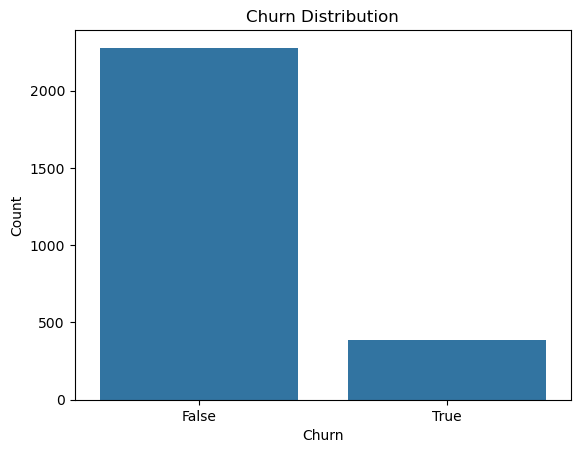

In [26]:
sns.countplot(x="Churn", data=df_fe)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [27]:
# Churn rate
df_fe["Churn"].value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

In [28]:
# Confirm no missing values remain
df_fe.isnull().sum().sort_values(ascending=False)

Account length               0
Number vmail messages        0
account_length_group_mid     0
Voice mail plan_1            0
International plan_1         0
intl_usage_ratio             0
total_charges                0
total_minutes                0
vmail_plan_flag              0
intl_plan_flag               0
high_service_calls           0
day_cost_per_min             0
day_intensity                0
Churn                        0
Customer service calls       0
Total intl charge            0
Total intl calls             0
Total intl minutes           0
Total night charge           0
Total night calls            0
Total night minutes          0
Total eve charge             0
Total eve calls              0
Total eve minutes            0
Total day charge             0
Total day calls              0
Total day minutes            0
account_length_group_long    0
dtype: int64

In [29]:
# Percentage missing (should be 0s)
(df_fe.isnull().mean() * 100).sort_values(ascending=False)

Account length               0.0
Number vmail messages        0.0
account_length_group_mid     0.0
Voice mail plan_1            0.0
International plan_1         0.0
intl_usage_ratio             0.0
total_charges                0.0
total_minutes                0.0
vmail_plan_flag              0.0
intl_plan_flag               0.0
high_service_calls           0.0
day_cost_per_min             0.0
day_intensity                0.0
Churn                        0.0
Customer service calls       0.0
Total intl charge            0.0
Total intl calls             0.0
Total intl minutes           0.0
Total night charge           0.0
Total night calls            0.0
Total night minutes          0.0
Total eve charge             0.0
Total eve calls              0.0
Total eve minutes            0.0
Total day charge             0.0
Total day calls              0.0
Total day minutes            0.0
account_length_group_long    0.0
dtype: float64

In [30]:
# Summary statistics for numeric variables
df_fe.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,2666.0,-1.292623e-16,1.000188,-2.518430,-0.698251,-0.015684,0.666883,3.599393
Number vmail messages,2666.0,-2.665202e-17,1.000188,-0.589414,-0.589414,-0.589414,0.806647,3.084430
Total day minutes,2666.0,1.399231e-16,1.000188,-3.311458,-0.665710,0.008642,0.671924,3.160845
Total day calls,2666.0,2.212117e-16,1.000188,-5.019422,-0.666029,0.034517,0.685024,2.986818
Total day charge,2666.0,-2.198791e-16,1.000188,-3.311525,-0.665553,0.008421,0.671543,3.161231
Total eve minutes,2666.0,-1.119385e-16,1.000188,-3.933617,-0.688748,0.010087,0.681439,3.205881
Total eve calls,2666.0,3.104960e-16,1.000188,-4.962065,-0.646088,-0.001172,0.693353,3.471452
Total eve charge,2666.0,2.811788e-16,1.000188,-3.933688,-0.688923,0.010838,0.680576,3.204795
Total night minutes,2666.0,5.996704e-16,1.000188,-3.101565,-0.674481,-0.000373,0.695401,3.817767
Total night calls,2666.0,-2.198791e-17,1.000188,-3.456440,-0.675059,-0.005468,0.664124,3.393998


In [31]:
num_cols = df_fe.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['Account length', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'day_intensity', 'day_cost_per_min', 'high_service_calls',
       'intl_plan_flag', 'vmail_plan_flag', 'total_minutes', 'total_charges',
       'intl_usage_ratio'],
      dtype='object')

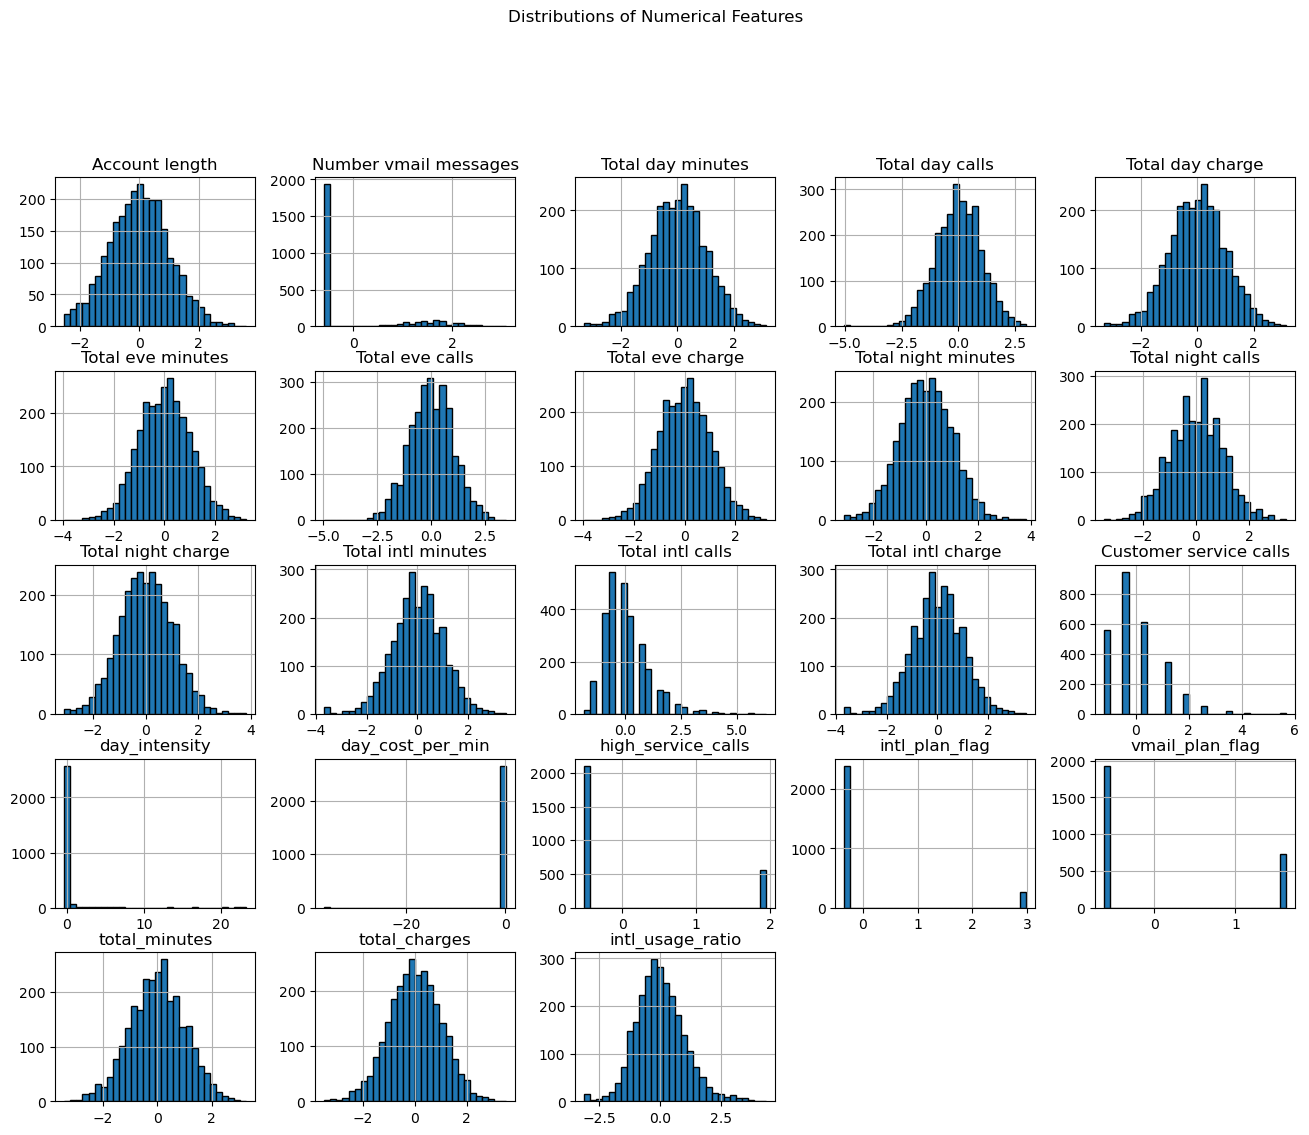

In [32]:
df_fe[num_cols].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor="black"
)
plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.show()

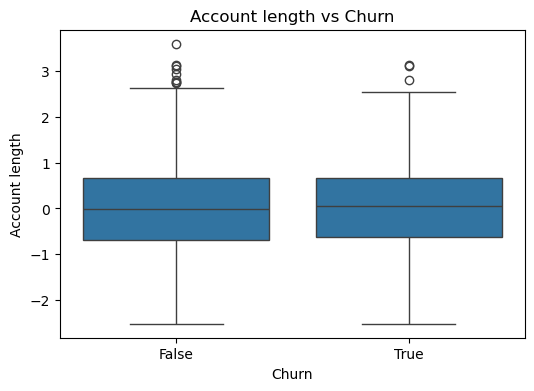

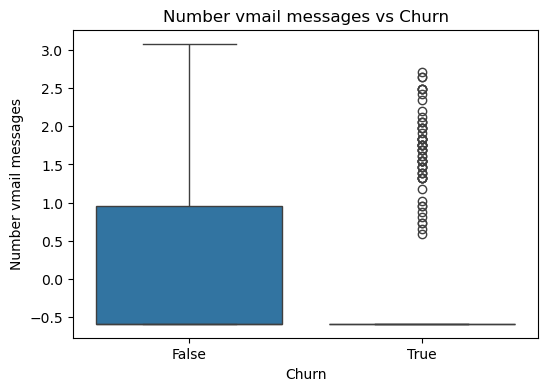

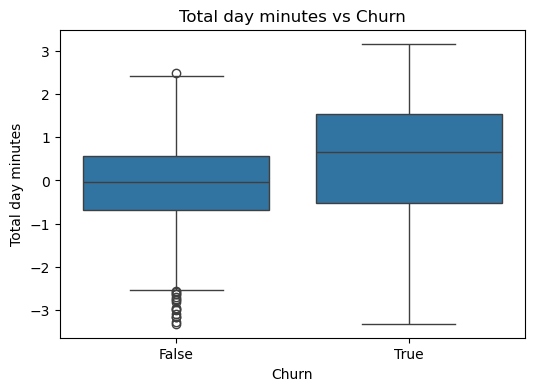

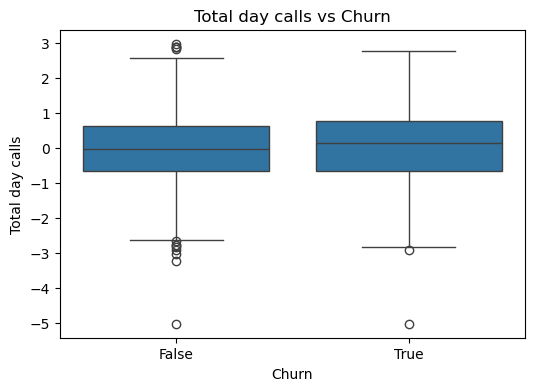

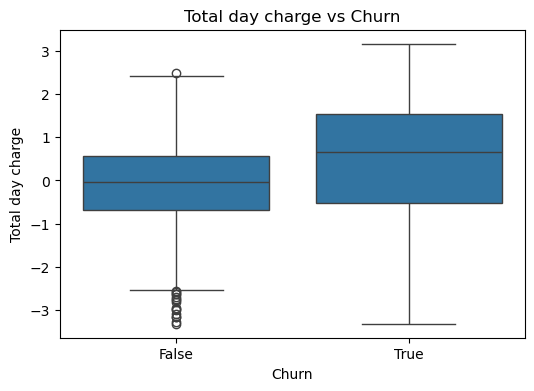

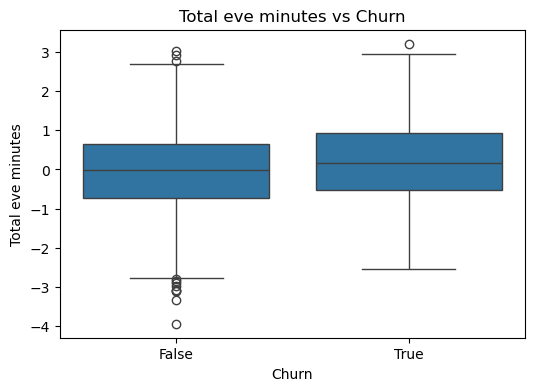

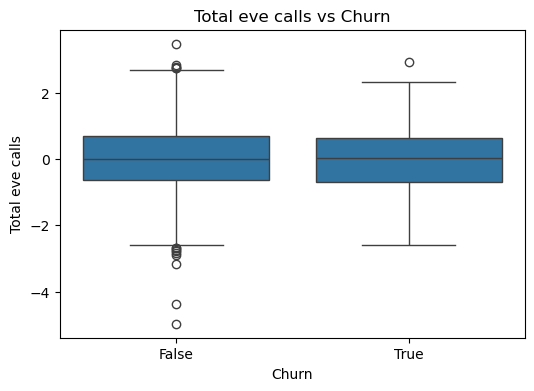

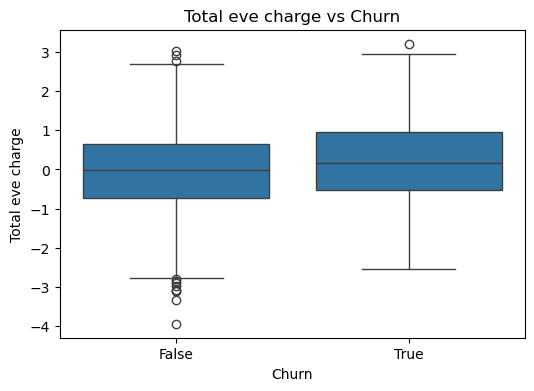

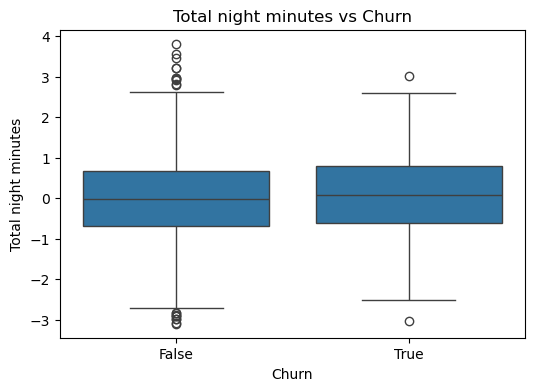

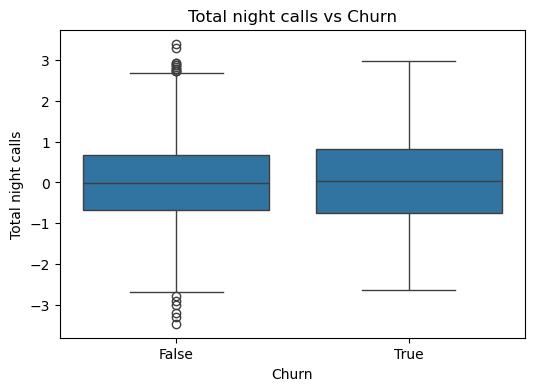

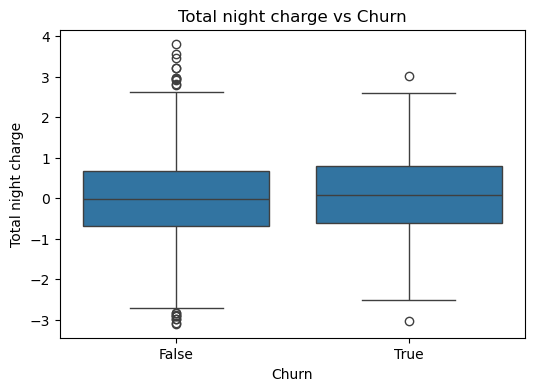

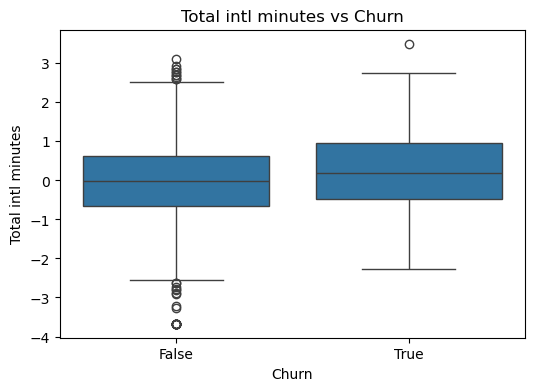

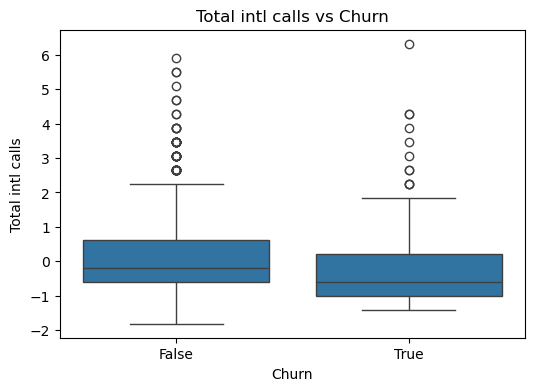

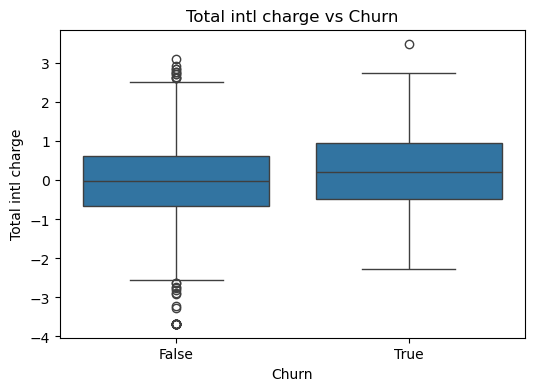

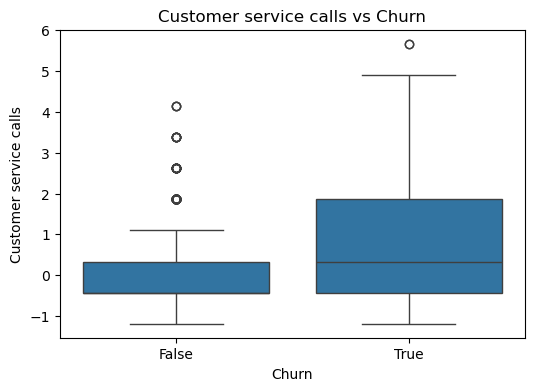

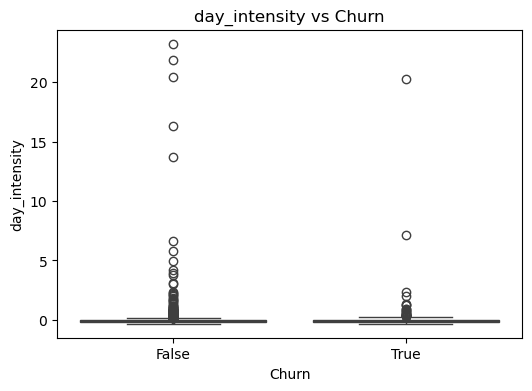

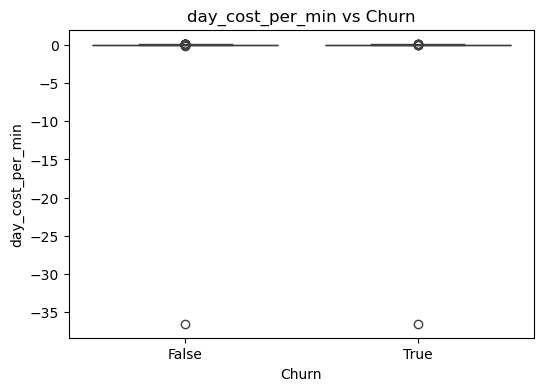

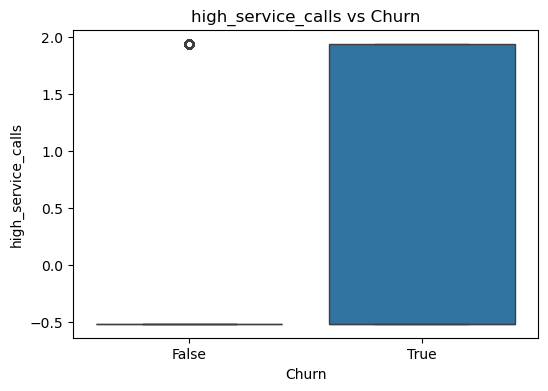

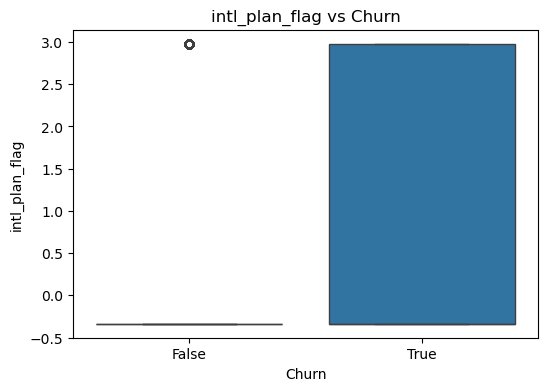

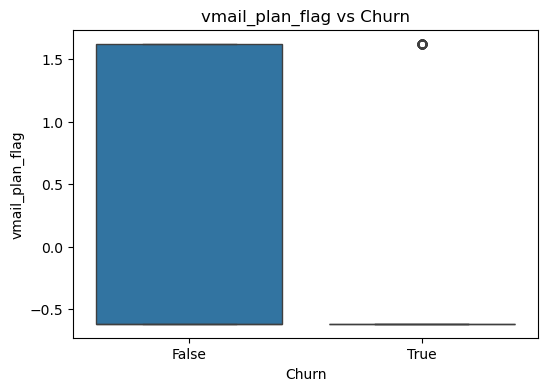

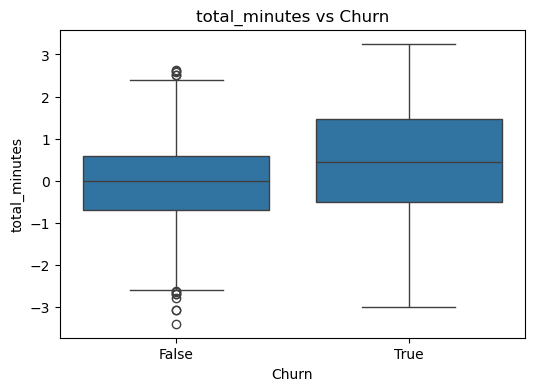

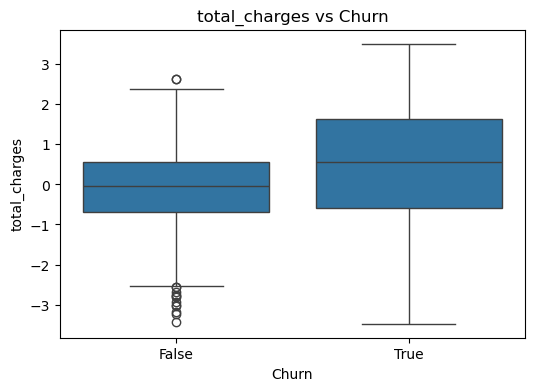

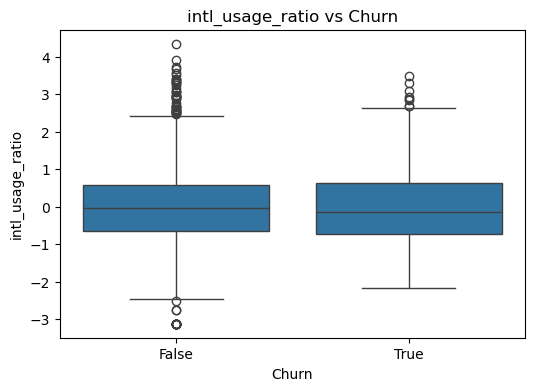

In [33]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Churn", y=col, data=df_fe)
    plt.title(f"{col} vs Churn")
    plt.show()

In [34]:
cat_cols = df_fe.select_dtypes(include=["object", "category"]).columns
cat_cols

Index([], dtype='object')

In [35]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="Churn", data=df_fe)
    plt.title(f"{col} by Churn")
    plt.xticks(rotation=45)
    plt.show()

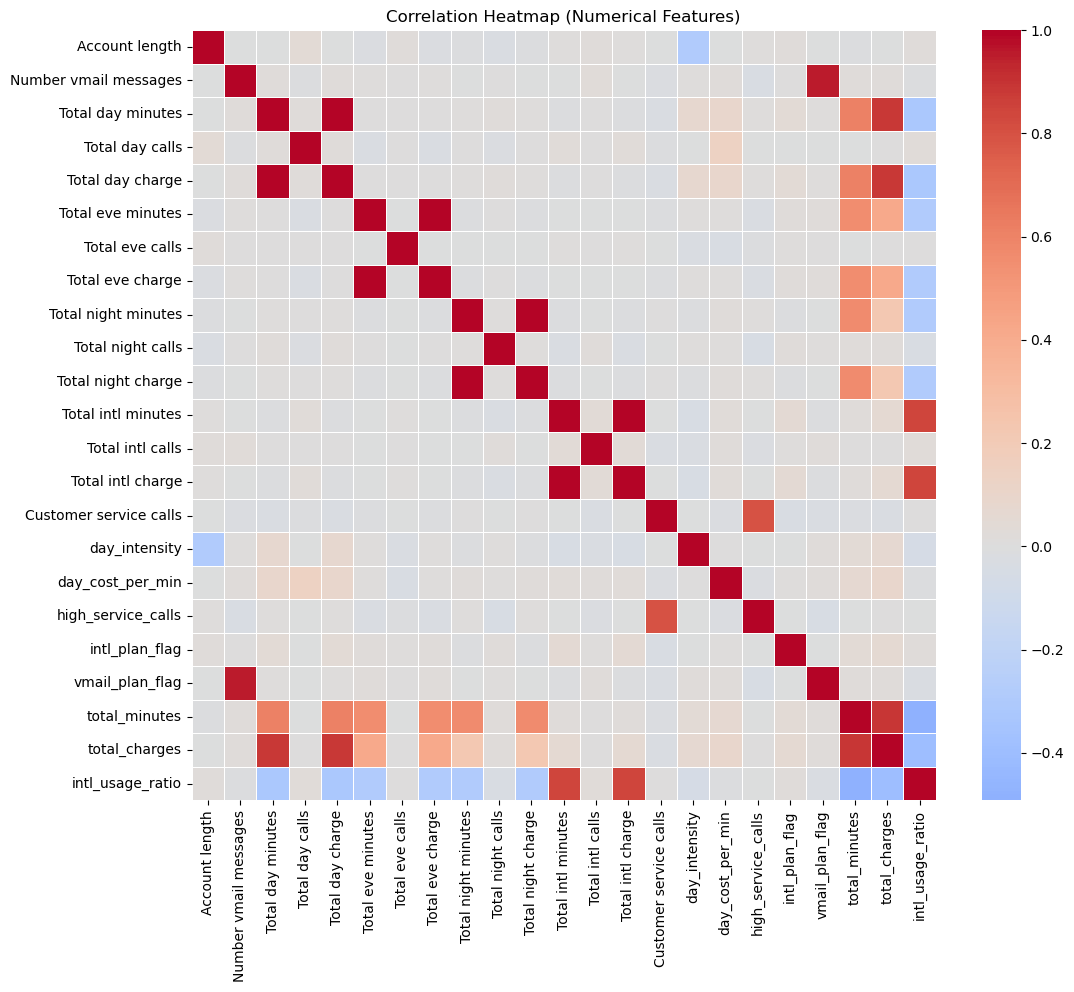

In [36]:
corr_matrix = df_fe[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [37]:
df_fe.groupby("Churn")[num_cols].mean().T

Churn,False,True
Account length,-0.007316,0.042956
Number vmail messages,0.035688,-0.209531
Total day minutes,-0.080761,0.474160
Total day calls,-0.007548,0.044318
Total day charge,-0.080762,0.474163
Total eve minutes,-0.030089,0.176655
Total eve calls,0.000635,-0.003729
Total eve charge,-0.030083,0.176623
Total night minutes,-0.013883,0.081509
Total night calls,-0.005061,0.029711


In [38]:
# Numeric columns only (exclude target)
num_cols = df_fe.select_dtypes(include=["int64", "float64"]).columns

# Compute correlation against boolean churn (implicitly treated as 0/1)
churn_corr = (
    df_fe[num_cols]
    .apply(lambda x: x.corr(df_fe["Churn"]))
    .sort_values(ascending=False)
)

churn_corr

intl_plan_flag            0.277489
total_charges             0.215695
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
total_minutes             0.180345
high_service_calls        0.174635
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
day_intensity             0.018365
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Total eve calls          -0.001539
intl_usage_ratio         -0.001969
day_cost_per_min         -0.027579
Total intl calls         -0.069882
Number vmail messages    -0.086474
vmail_plan_flag          -0.099291
dtype: float64

Logistic Regression Results
Accuracy: 0.8689138576779026
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       455
           1       0.65      0.25      0.36        79

    accuracy                           0.87       534
   macro avg       0.76      0.61      0.65       534
weighted avg       0.85      0.87      0.84       534



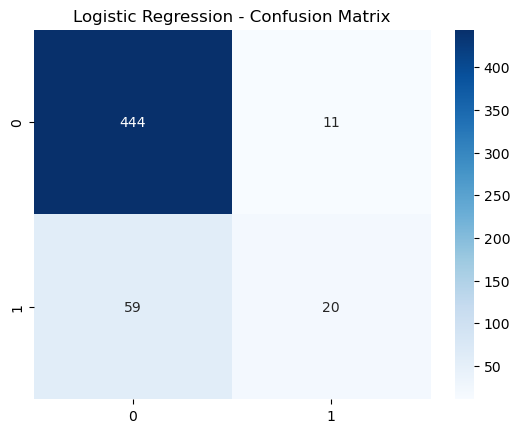

In [39]:
# Logistic Regression Baseline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Random Forest Results
Accuracy: 0.9719101123595506
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       455
           1       1.00      0.81      0.90        79

    accuracy                           0.97       534
   macro avg       0.98      0.91      0.94       534
weighted avg       0.97      0.97      0.97       534



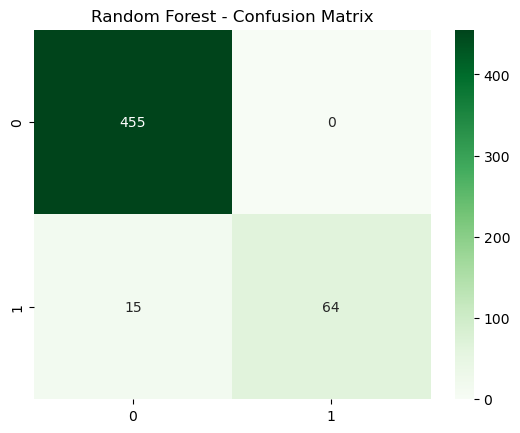

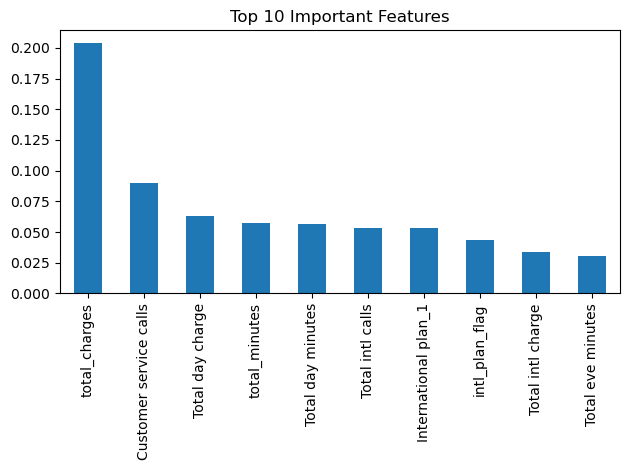

In [40]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

# Build and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Feature importance
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

XGBoost Results
Accuracy: 0.9756554307116105
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       455
           1       1.00      0.84      0.91        79

    accuracy                           0.98       534
   macro avg       0.99      0.92      0.95       534
weighted avg       0.98      0.98      0.97       534



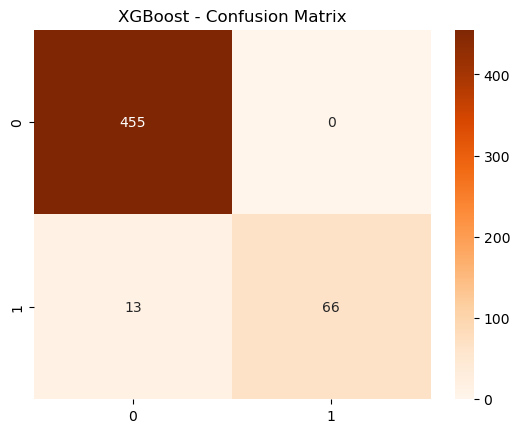

In [41]:
# XGBoost
from xgboost import XGBClassifier

# Build and train the model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [42]:
#Neural Network

In [43]:
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '--quiet'])


0

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

In [ ]:

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert boolean target to int (0/1)
y_train_nn = y_train_nn.astype(int).values
y_test_nn  = y_test_nn.astype(int).values

print(f"Training samples : {X_train_nn.shape[0]}")
print(f"Test samples     : {X_test_nn.shape[0]}")
print(f"Number of features: {X_train_nn.shape[1]}")
print(f"\nChurn rate in train: {y_train_nn.mean():.2%}")
print(f"Churn rate in test : {y_test_nn.mean():.2%}")

In [ ]:
input_dim = X_train_nn.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')   # sigmoid → probability of churn
], name="Churn_NN")

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [2]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_nn)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_nn)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:", class_weight_dict)

NameError: name 'np' is not defined

In [3]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

NameError: name 'keras' is not defined

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Neural Network Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

cm = confusion_matrix(y_test_nn, y_pred_nn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Neural Network - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_nn, y_prob_nn)
auc_score   = roc_auc_score(y_test_nn, y_prob_nn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f"NN  (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "F1 (Churn)": f1_score(y_test, y_pred_lr)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "F1 (Churn)": f1_score(y_test, y_pred_rf)
    },
    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "F1 (Churn)": f1_score(y_test, y_pred_xgb)
    },
    "Neural Network": {
        "Accuracy": accuracy_score(y_test_nn, y_pred_nn),
        "F1 (Churn)": f1_score(y_test_nn, y_pred_nn)
    }
}

comparison_df = pd.DataFrame(results).T
print(comparison_df.round(4))

# Bar chart
comparison_df.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='black')
plt.title("Model Comparison: Accuracy & F1 Score (Churn Class)")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [2]:
print(df["Churn"].value_counts())
print()

NameError: name 'df' is not defined